Proportion of seats held by women in national parliaments (%)
Women in parliaments are the percentage of parliamentary seats in a single or lower chamber held by women.

ID: WB_GS_SG_GEN_PARL_ZS
https://data360.worldbank.org/en/indicator/WB_GS_SG_GEN_PARL_ZS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("WB_GS_SG_GEN_PARL_ZS.csv")

In [3]:
# Source of African countries list: UNSD: https://unstats.un.org/unsd/methodology/m49/overview/
# Some of the names have been manually adapted to match the World Bank's encoding

africa_countries = [
    'Algeria',
    'Angola', 
    'Burundi', 
    'Benin', 
    'Burkina Faso',
    'Botswana', 
    'British Indian Ocean Territory',
    'Central African Republic', 
    "Cote d'Ivoire", 
    'Cameroon',
    'Congo, Dem. Rep.', 
    'Congo, Rep.', 
    'Comoros',
    'Cabo Verde',
    'Djibouti', 
    'Egypt, Arab Rep.',
    'Eritrea',
    'Ethiopia',
    'French Southern Territories',
    'Gabon',
    'Ghana', 
    'Guinea', 
    'Gambia, The', 
    'Guinea-Bissau',
    'Equatorial Guinea',  
    'Kenya',
    'Liberia', 
    'Libya', 
    'Lesotho',
    'Madagascar',
    'Morocco',  
    'Mali',
    'Mozambique', 
    'Mauritania',
    'Mauritius', 
    'Malawi',
    'Mayotte',
    'Namibia',
    'Niger', 
    'Nigeria', 
    'Reunion',
    'Rwanda',  
    'Saint Helena',
    'Sudan', 
    'Senegal', 
    'Sierra Leone', 
    'Somalia', 
    'South Sudan',
    'Sao Tome and Principe',
    'Eswatini',
    'Seychelles', 
    'Chad',
    'Tanzania',
    'Togo', 
    'Tunisia',
    'Uganda',
    'South Africa',
    'Western Sahara',
    'Zambia', 
    'Zimbabwe']

In [4]:
df_africa = df[df['REF_AREA_LABEL'].isin(africa_countries)]

In [5]:
df_africa_selected = df_africa[['REF_AREA_LABEL','OBS_VALUE','TIME_PERIOD']].dropna()

In [6]:
df_africa_selected.sort_values(by=['REF_AREA_LABEL', 'TIME_PERIOD'], ascending=False, inplace=True)

In [7]:
df_africa_selected['Area'] = 'Parliament'

In [8]:
df_africa_selected[df_africa_selected['TIME_PERIOD'] > 1999].to_csv("parliament.csv", index=False)

In [9]:
df_africa_selected['TIME_PERIOD'].sort_values()

9865     1997
9891     1997
9809     1997
9952     1997
9824     1997
         ... 
16518    2022
16463    2022
16486    2022
16597    2022
16694    2022
Name: TIME_PERIOD, Length: 1293, dtype: int64

# Exploration & Charts

## Let's find out where greatest change has happened

In [10]:
# Get earliest and latest year per country
first_last = (
    df_africa_selected.sort_values('TIME_PERIOD')
      .groupby('REF_AREA_LABEL')
      .agg(
          first_value=('OBS_VALUE', 'first'),
          last_value=('OBS_VALUE', 'last')
      )
)

# Calculate positive change
first_last['change'] = first_last['last_value'] - first_last['first_value']

# Order countries by change descending
ordered_countries = first_last.sort_values('change', ascending=False).index.tolist()

In [11]:
df_africa_selected['REF_AREA_LABEL'] = pd.Categorical(df_africa_selected['REF_AREA_LABEL'], categories=ordered_countries, ordered=True)

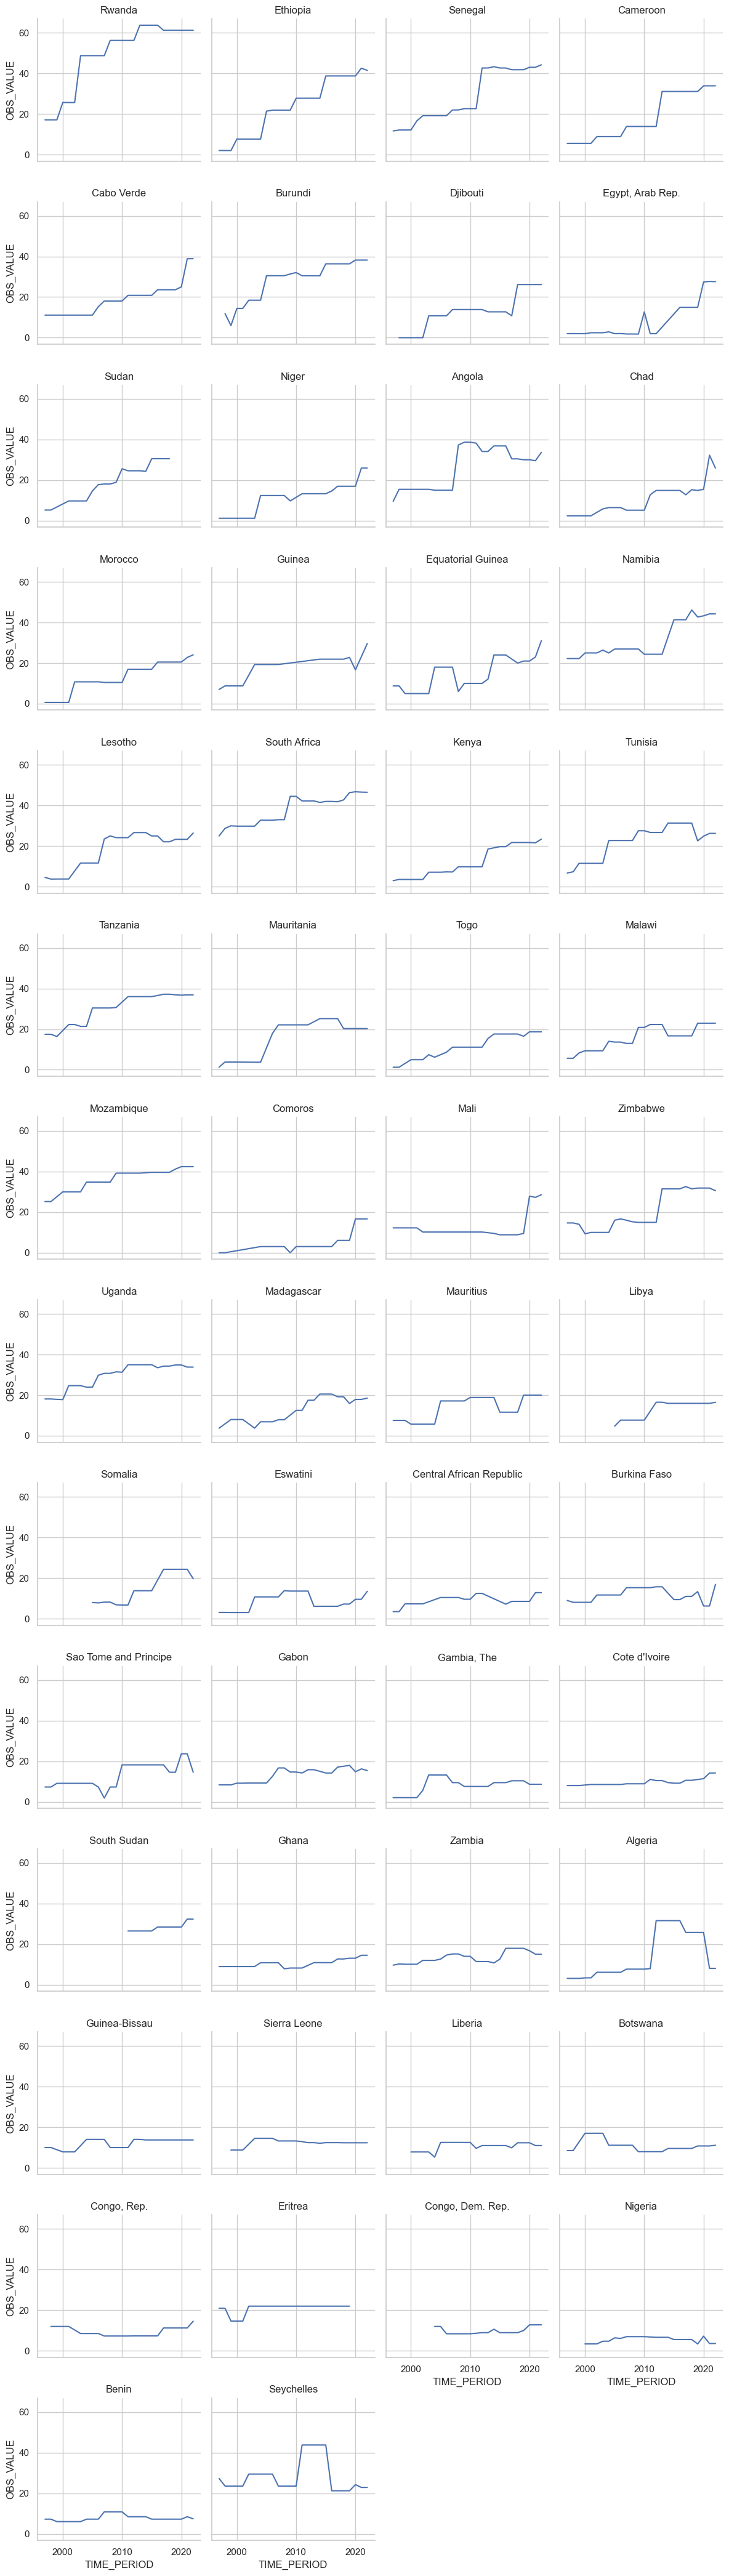

In [12]:
sns.set(style="whitegrid")
g = sns.FacetGrid(
    df_africa_selected, 
    col='REF_AREA_LABEL', 
    col_wrap=4, 
    height=3, 
    sharey=True
)
g.map(sns.lineplot, 'TIME_PERIOD', 'OBS_VALUE')
g.set_titles("{col_name}")
plt.tight_layout()

plt.savefig('parliament.png', dpi=300)

plt.show()

## All and evolution

In [13]:
# For regional evolution chart
africa_evolution = df_africa_selected.groupby('TIME_PERIOD')['OBS_VALUE'].median()

In [14]:
africa_evolution = pd.DataFrame(africa_evolution)

In [15]:
africa_evolution['min'] = df_africa_selected.groupby('TIME_PERIOD')['OBS_VALUE'].min()

In [16]:
africa_evolution['max'] = df_africa_selected.groupby('TIME_PERIOD')['OBS_VALUE'].max()

In [47]:
africa_evolution['Rwanda'] = df_africa_selected[df_africa_selected['REF_AREA_LABEL'] == 'Rwanda'].sort_values(by='TIME_PERIOD')['OBS_VALUE'].to_list()

In [58]:
nigeria = df_africa_selected[df_africa_selected['REF_AREA_LABEL'] == 'Nigeria'].sort_values(by='TIME_PERIOD')['OBS_VALUE'].to_list()

In [59]:
nigeria = [0, 0, 0] + nigeria

In [60]:
africa_evolution['Nigeria'] = nigeria

In [61]:
africa_evolution.to_csv("Parliament_evolution_median_all.csv")

## Latest All

In [18]:
# Sort so the latest TIME_PERIOD comes first for each REF_AREA_LABEL
df_sorted = df_africa_selected.sort_values(['REF_AREA_LABEL', 'TIME_PERIOD'], ascending=[True, False])
# Keep only the first entry for each REF_AREA_LABEL
df_latest = df_sorted.drop_duplicates('REF_AREA_LABEL', keep='first')

In [19]:
df_latest.to_csv("parliament_mostRecentYear_all.csv", index=False)

## Outliers

In [20]:
df_africa_selected

,REF_AREA_LABEL,OBS_VALUE,TIME_PERIOD,Area
16694,Zimbabwe,30.566038,2022,Parliament
16429,Zimbabwe,31.851852,2021,Parliament
16164,Zimbabwe,31.851852,2020,Parliament
15899,Zimbabwe,31.851852,2019,Parliament
15634,Zimbabwe,31.481481,2018,Parliament
...,...,...,...,...
10925,Algeria,3.421053,2001,Parliament
10660,Algeria,3.421053,2000,Parliament
10395,Algeria,3.157895,1999,Parliament
10130,Algeria,3.157895,1998,Parliament


In [21]:
df_outliers = df_africa_selected[df_africa_selected['REF_AREA_LABEL'].isin(['Rwanda', 'Ethiopia', 'Senegal', 'Cameroon'])]

In [22]:
df_outliers_pivot = df_outliers.pivot(
    index='TIME_PERIOD',
    columns='REF_AREA_LABEL',
    values='OBS_VALUE')

In [23]:
df_outliers_pivot.to_csv("parliament_topChange.csv")

## Small multiples charts with median

In [24]:
df_africa_selected_pivot = df_africa_selected.pivot(
    index='TIME_PERIOD',
    columns='REF_AREA_LABEL',
    values='OBS_VALUE').reset_index()

In [25]:
df_africa_selected_pivot = df_africa_selected_pivot.merge(africa_evolution, on='TIME_PERIOD', how='outer')

In [26]:
df_africa_selected_pivot = df_africa_selected_pivot[df_africa_selected_pivot['TIME_PERIOD'] > 1999]

In [27]:
df_africa_selected_pivot.to_csv("smallMultiples.csv", index=False)